# Part A: Word Embeddings

This notebook explores pre-trained word embeddings (Word2Vec and GloVe) using `gensim`.  
We will examine word similarities, analogies, and visualize embeddings with t-SNE.

## 0. Φόρτωμα μοντέλων

In [1]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

sns.set_style("whitegrid")

print("Loading Word2Vec (Google News 300d)...")
w2v_model = api.load('word2vec-google-news-300')
print("Done.")

print("Loading GloVe (Wiki Gigaword 300d)...")
glove_model = api.load('glove-wiki-gigaword-300')
print("Done.")

Loading Word2Vec (Google News 300d)...
Done.
Loading GloVe (Wiki Gigaword 300d)...
Done.


## 1. Top-10 Κοντινές λέξεις

Για κάθε μία από τις: **'car'**, **'jaguar'**, **'Jaguar'**, **'facebook'**.

In [7]:
def top_ten_w2v_glove(query_words):
    w2v_results = {}
    glove_results = {}

    for word in query_words:
        print(f"\n{'='*60}")
        print(f"  Word: '{word}'")
        print(f"{'='*60}")

        # Word2Vec
        try:
            w2v_similar = w2v_model.most_similar(word, topn=10)
            w2v_results[word] = [w for w, _ in w2v_similar]
            print(f"\n  Word2Vec top-10:")
            for rank, (w, score) in enumerate(w2v_similar, 1):
                print(f"    {rank:2d}. {w:<25s} {score:.4f}")
        except KeyError:
            print(f"  Word2Vec: '{word}' not in vocabulary")
            w2v_results[word] = []

        # GloVe
        try:
            glove_similar = glove_model.most_similar(word, topn=10)
            glove_results[word] = [w for w, _ in glove_similar]
            print(f"\n  GloVe top-10:")
            for rank, (w, score) in enumerate(glove_similar, 1):
                print(f"    {rank:2d}. {w:<25s} {score:.4f}")
        except KeyError:
            print(f"  GloVe: '{word}' not in vocabulary (GloVe is lowercase-only)")
            glove_results[word] = []

    return w2v_results, glove_results


In [8]:
query_words = ['car', 'jaguar', 'Jaguar', 'facebook']
w2v_results, glove_results = top_ten_w2v_glove(query_words)


  Word: 'car'

  Word2Vec top-10:
     1. vehicle                   0.7821
     2. cars                      0.7424
     3. SUV                       0.7161
     4. minivan                   0.6907
     5. truck                     0.6736
     6. Car                       0.6678
     7. Ford_Focus                0.6673
     8. Honda_Civic               0.6627
     9. Jeep                      0.6511
    10. pickup_truck              0.6441

  GloVe top-10:
     1. cars                      0.7827
     2. vehicle                   0.7655
     3. truck                     0.7351
     4. driver                    0.7115
     5. driving                   0.6442
     6. vehicles                  0.6328
     7. motorcycle                0.6023
     8. automobile                0.5956
     9. parked                    0.5910
    10. drivers                   0.5778

  Word: 'jaguar'

  Word2Vec top-10:
     1. jaguars                   0.6738
     2. Macho_B                   0.6313
     3. 

| original word | ranking | word2vec value | word2vec score | glove value | glove score |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **car** | 1 | ***vehicle*** | 0.7821 | ***cars*** | 0.7827 |
| | 2 | ***cars*** | 0.7424 | ***vehicle*** | 0.7655 |
| | 3 | SUV | 0.7161 | ***truck*** | 0.7351 |
| | 4 | minivan | 0.6907 | driver | 0.7115 |
| | 5 | ***truck*** | 0.6736 | driving | 0.6442 |
| | 6 | Car | 0.6678 | vehicles | 0.6328 |
| | 7 | Ford_Focus | 0.6673 | motorcycle | 0.6023 |
| | 8 | Honda_Civic | 0.6627 | automobile | 0.5956 |
| | 9 | Jeep | 0.6511 | parked | 0.5910 |
| | 10 | pickup_truck | 0.6441 | drivers | 0.5778 |
| --- | --- | --- | --- | --- | --- |
| **jaguar** | 1 | jaguars | 0.6738 | rover | 0.5931 |
| | 2 | Macho_B | 0.6313 | bmw | 0.5415 |
| | 3 | panther | 0.6086 | mercedes | 0.5256 |
| | 4 | lynx | 0.5815 | sepecat | 0.5030 |
| | 5 | rhino | 0.5754 | mustang | 0.4987 |
| | 6 | lizard | 0.5607 | lexus | 0.4845 |
| | 7 | tapir | 0.5563 | volvo | 0.4829 |
| | 8 | tiger | 0.5529 | cosworth | 0.4809 |
| | 9 | leopard | 0.5473 | xk | 0.4764 |
| | 10 | Florida_panther | 0.5464 | maserati | 0.4757 |
| --- | --- | --- | --- | --- | --- |
| **Jaguar** | 1 | Land_Rover | 0.6484 | N/A | - |
| | 2 | Aston_Martin | 0.6437 | N/A | - |
| | 3 | Mercedes | 0.6420 | N/A | - |
| | 4 | Porsche | 0.6233 | N/A | - |
| | 5 | BMW | 0.6055 | N/A | - |
| | 6 | Bentley_Arnage | 0.6040 | N/A | - |
| | 7 | XF_sedan | 0.5996 | N/A | - |
| | 8 | Audi | 0.5976 | N/A | - |
| | 9 | Jaguar_XF | 0.5951 | N/A | - |
| | 10 | XJ_saloon | 0.5942 | N/A | - |
| --- | --- | --- | --- | --- | --- |
| **facebook** | 1 | Facebook | 0.7564 | ***twitter*** | 0.8350 |
| | 2 | FaceBook | 0.7077 | ***myspace*** | 0.8056 |
| | 3 | ***twitter*** | 0.6989 | youtube | 0.7292 |
| | 4 | ***myspace*** | 0.6942 | blog | 0.6404 |
| | 5 | Twitter | 0.6642 | ***linkedin*** | 0.6333 |
| | 6 | twitter_facebook | 0.6572 | google | 0.6268 |
| | 7 | Facebook.com | 0.6530 | website | 0.6157 |
| | 8 | myspace_facebook | 0.6371 | web | 0.6143 |
| | 9 | facebook_twitter | 0.6368 | blogs | 0.6064 |
| | 10 | ***linkedin*** | 0.6357 | networking | 0.6047 |

### Κοινές λέξεις

In [9]:
for word in query_words:
    w2v_set = set(w.lower() for w in w2v_results.get(word, []))
    glove_set = set(w.lower() for w in glove_results.get(word, []))
    common = w2v_set & glove_set
    print(f"'{word}': {len(common)} common words -> {common if common else '{}'} ")

'car': 3 common words -> {'truck', 'cars', 'vehicle'} 
'jaguar': 0 common words -> {} 
'Jaguar': 0 common words -> {} 
'facebook': 3 common words -> {'myspace', 'linkedin', 'twitter'} 


Παρατηρούμε πως ενώ για τα car και facebook βρέθηκαν από 3 κοινές λέξεις, για τα jaguar/Jaguar δεν εχουμε καμία.
Για την λέξη Jaguar είναι αρκετά προφανές πως αφού το glove δεν έχει κεφαλαία, δεν βρίσκει καθόλου το κλειδί για να βρεθούν ομοιότητες, και το word2vec φέρνει οχηματα σαν πλησιέστερες λέξεις. 

Για το jaguar (με μικρό j) ομως, είναι αξιοσημείωτο ότι ενώ το word2vec φέρνει ζώα σαν πλησιέστερες έννοιες, το glove φέρνει οχήματα! καταλαβαίνουμε λοιπόν οτι το word2vec κάνει εναν επιπλέον διαχωρισμό των δύο εννοιών με την χρήση κεφαλαίων, και συνδέει το Jaguar με την γνωστή αυτοκινητοβιομηχανία και το jaguar με το αιλουροειδές.

## 2. Τέσσερεις Λέξεις Δικής μου επιλογής: python, coffee, galaxy, tennis

*θα χρησιμοποιηθεί η function που δημηουργήθηκε στο προηγούμενο ερώτημα.*

In [10]:
custom_words = ['python', 'coffee', 'galaxy', 'tennis']
w2v_results_custom, glove_results_custom = top_ten_w2v_glove(custom_words)



  Word: 'python'

  Word2Vec top-10:
     1. pythons                   0.6688
     2. Burmese_python            0.6680
     3. snake                     0.6606
     4. crocodile                 0.6591
     5. boa_constrictor           0.6444
     6. alligator                 0.6422
     7. reptile                   0.6388
     8. albino_python             0.6159
     9. croc                      0.6084
    10. lizard                    0.6013

  GloVe top-10:
     1. monty                     0.6837
     2. perl                      0.5193
     3. cleese                    0.5092
     4. pythons                   0.5007
     5. php                       0.4942
     6. grail                     0.4683
     7. scripting                 0.4676
     8. skit                      0.4475
     9. javascript                0.4313
    10. spamalot                  0.4312

  Word: 'coffee'

  Word2Vec top-10:
     1. coffees                   0.7213
     2. gourmet_coffee            0.7057
     

| original word | ranking | word2vec value | word2vec score | glove value | glove score |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **python** | 1 | pythons | 0.6688 | monty | 0.6837 |
| | 2 | Burmese_python | 0.6680 | perl | 0.5193 |
| | 3 | snake | 0.6606 | cleese | 0.5092 |
| | 4 | crocodile | 0.6591 | pythons | 0.5007 |
| | 5 | boa_constrictor | 0.6444 | php | 0.4942 |
| | 6 | alligator | 0.6422 | grail | 0.4683 |
| | 7 | reptile | 0.6388 | scripting | 0.4676 |
| | 8 | albino_python | 0.6159 | skit | 0.4475 |
| | 9 | croc | 0.6084 | javascript | 0.4313 |
| | 10 | lizard | 0.6013 | spamalot | 0.4312 |
| --- | --- | --- | --- | --- | --- |
| **coffee** | 1 | coffees | 0.7213 | tea | 0.6692 |
| | 2 | gourmet_coffee | 0.7057 | espresso | 0.5902 |
| | 3 | Coffee | 0.6900 | cocoa | 0.5678 |
| | 4 | o_joe | 0.6891 | starbucks | 0.5498 |
| | 5 | Starbucks_coffee | 0.6875 | drinks | 0.5467 |
| | | coffee_beans | 0.6750 | beans | 0.5412 |
| | 7 | latté | 0.6641 | drink | 0.5403 |
| | 8 | cappuccino | 0.6625 | beer | 0.5283 |
| | 9 | brewed_coffee | 0.6622 | sipping | 0.5049 |
| | 10 | espresso | 0.6617 | sugar | 0.5025 |
| --- | --- | --- | --- | --- | --- |
| **galaxy** | 1 | galaxies | 0.7880 | galaxies | 0.5894 |
| | 2 | Milky_Way_galaxy | 0.7715 | planets | 0.4908 |
| | 3 | Milky_Way_Galaxy | 0.7398 | milky | 0.4863 |
| | 4 | Milky_Way | 0.7311 | ngc | 0.4801 |
| | 5 | distant_galaxy | 0.7264 | mls | 0.4729 |
| | 6 | Andromeda_galaxy | 0.7250 | planet | 0.4572 |
| | 7 | planets | 0.7234 | andromeda | 0.4472 |
| | 8 | supernova | 0.7081 | stars | 0.4469 |
| | 9 | nebula | 0.7063 | universe | 0.4385 |
| | 10 | galactic | 0.7018 | star | 0.4293 |
| --- | --- | --- | --- | --- | --- |
| **tennis** | 1 | Tennis | 0.7291 | badminton | 0.6591 |
| | 2 | volleyball | 0.6842 | tournament | 0.6410 |
| | 3 | badminton | 0.6706 | volleyball | 0.6373 |
| | 4 | basketball | 0.6559 | wimbledon | 0.6204 |
| | 5 | soccer | 0.6163 | atp | 0.6107 |
| | 6 | beach_volleyball | 0.6127 | wta | 0.6054 |
| | 7 | Steffi_Graff | 0.6038 | golf | 0.6036 |
| | 8 | André_Agassi | 0.5987 | championships | 0.6009 |
| | 9 | golf | 0.5907 | tournaments | 0.5826 |
| | 10 | TENNIS | 0.5898 | basketball | 0.5690 |

### Κοινές λέξεις

In [11]:
for word in custom_words:
    w2v_set = set(w.lower() for w in w2v_results_custom.get(word, []))
    glove_set = set(w.lower() for w in glove_results_custom.get(word, []))
    common = w2v_set & glove_set
    print(f"'{word}': {len(common)} common words -> {common if common else '{}'} ")

'python': 1 common words -> {'pythons'} 
'coffee': 1 common words -> {'espresso'} 
'galaxy': 2 common words -> {'galaxies', 'planets'} 
'tennis': 4 common words -> {'basketball', 'golf', 'badminton', 'volleyball'} 


## 3. Τοπ-10 κοντινές λέξεις στο Student

In [12]:
print("Top-10 closest words to 'student':\n")
for model_name, model_obj in [('Word2Vec', w2v_model), ('GloVe', glove_model)]:
    try:
        similar = model_obj.most_similar('student', topn=10)
        print(f"  {model_name}:")
        for rank, (w, score) in enumerate(similar, 1):
            print(f"    {rank:2d}. {w:<25s} {score:.4f}")
        print()
    except KeyError:
        print(f"  {model_name}: 'student' not in vocabulary")

Top-10 closest words to 'student':



  Word2Vec:
     1. students                  0.7295
     2. Student                   0.6707
     3. teacher                   0.6301
     4. stu_dent                  0.6241
     5. faculty                   0.6087
     6. school                    0.6056
     7. undergraduate             0.6020
     8. university                0.6005
     9. undergraduates            0.5756
    10. semester                  0.5738

  GloVe:
     1. students                  0.7691
     2. teacher                   0.6874
     3. graduate                  0.6738
     4. school                    0.6131
     5. college                   0.6090
     6. undergraduate             0.6044
     7. faculty                   0.5999
     8. university                0.5971
     9. academic                  0.5810
    10. campus                    0.5768



| original word | ranking | word2vec value | word2vec score | glove value | glove score |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **student** | 1 | students | 0.7295 | students | 0.7691 |
| | 2 | Student | 0.6707 | teacher | 0.6874 |
| | 3 | teacher | 0.6301 | graduate | 0.6738 |
| | 4 | stu_dent | 0.6241 | school | 0.6131 |
| | 5 | faculty | 0.6087 | college | 0.6090 |
| | 6 | school | 0.6056 | undergraduate | 0.6044 |
| | 7 | undergraduate | 0.6020 | faculty | 0.5999 |
| | 8 | university | 0.6005 | university | 0.5971 |
| | 9 | undergraduates | 0.5756 | academic | 0.5810 |
| | 10 | semester | 0.5738 | campus | 0.5768 |

## 3. Student - αρνητικές συσχετίσεις

### Αρνητική συσχέτιση με φοιτητές Πανεπιστημίου

In [14]:
def find_similar_with_negative(negative_input):
    print(f"Top-10 closest to 'student'(wit negatives):\n")
    for model_name, model_obj in [('Word2Vec', w2v_model), ('GloVe', glove_model)]:
        try:
            similar = model_obj.most_similar(positive=['student'], negative=negative_input, topn=10)
            print(f"  {model_name}:")
            for rank, (w, score) in enumerate(similar, 1):
                print(f"    {rank:2d}. {w:<25s} {score:.4f}")
            print()
        except KeyError as e:
            print(f"  {model_name}: KeyError – {e}")

In [15]:
negative_university = ['university']
find_similar_with_negative(negative_university)



Top-10 closest to 'student'(wit negatives):

  Word2Vec:
     1. sixth_grader              0.4324
     2. seventh_grader            0.4178
     3. 8th_grader                0.4173
     4. eighth_grader             0.4082
     5. grader                    0.3971
     6. kindergartner             0.3918
     7. kindergartener            0.3777
     8. Kindergartner             0.3565
     9. teen                      0.3470
    10. middle_schooler           0.3384

  GloVe:
     1. 15-year                   0.3830
     2. 16-year                   0.3815
     3. 17-year                   0.3785
     4. 14-year                   0.3766
     5. 13-year-old               0.3730
     6. 14-year-old               0.3676
     7. 9-year                    0.3667
     8. 16-year-old               0.3615
     9. 15-year-old               0.3510
    10. 12-year-old               0.3490



η λίστα αλλάζει αμέσως και φέρνει λέξεις που περιγράφουν μαθητές σχολείου:

| original word | ranking | word2vec value | word2vec score | glove value | glove score |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **student** (negative: university/college) | 1 | sixth_grader | 0.4324 | 15-year | 0.3830 |
| | 2 | seventh_grader | 0.4178 | 16-year | 0.3815 |
| | 3 | 8th_grader | 0.4173 | 17-year | 0.3785 |
| | 4 | eighth_grader | 0.4082 | 14-year | 0.3766 |
| | 5 | grader | 0.3971 | 13-year-old | 0.3730 |
| | 6 | kindergartner | 0.3918 | 14-year-old | 0.3676 |
| | 7 | kindergartener | 0.3777 | 9-year | 0.3667 |
| | 8 | Kindergartner | 0.3565 | 16-year-old | 0.3615 |
| | 9 | teen | 0.3470 | 15-year-old | 0.3510 |
| | 10 | middle_schooler | 0.3384 | 12-year-old | 0.3490 |

Ας δούμε τι θα συμβεί αν βάλουμε και άλλες λεξεις για αρνητική συσχέτιση:

In [16]:
negative_university = ['university', 'college', 'professor', 'degree', 'campus']
find_similar_with_negative(negative_university)

Top-10 closest to 'student'(wit negatives):

  Word2Vec:
     1. IF_SEPT                   0.3779
     2. mso_para_margin_0in       0.3698
     3. M.Kenseth_###-###         0.3624
     4. Ky.Busch_##-###           0.3376
     5. J.McMurray_###-###        0.3307
     6. K.Kahne_###-###           0.3275
     7. ----------_-----------------------------------------------_GS## 0.3273
     8. SCHEDULED_TO_PREMIERE_4Q  0.3170
     9. E.Sadler_###-###          0.3158
    10. Nasdaq_NASDAQ_TRIN        0.3082

  GloVe:
     1. viewport                  0.4015
     2. pi95                      0.3984
     3. monechma                  0.3982
     4. gm2                       0.3957
     5. rungfapaisarn             0.3956
     6. thongrung                 0.3871
     7. beermakers                0.3854
     8. .0358                     0.3850
     9. .9998                     0.3828
    10. sakik                     0.3826



| original word | ranking | word2vec value | word2vec score | glove value | glove score |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **student** (negative: university/college) | 1 | IF_SEPT | 0.3779 | viewport | 0.4015 |
| | 2 | mso_para_margin_0in | 0.3698 | pi95 | 0.3984 |
| | 3 | M.Kenseth_###-### | 0.3624 | monechma | 0.3982 |
| | 4 | Ky.Busch_##-### | 0.3376 | gm2 | 0.3957 |
| | 5 | J.McMurray_###-### | 0.3307 | rungfapaisarn | 0.3956 |
| | 6 | K.Kahne_###-### | 0.3275 | thongrung | 0.3871 |
| | 7 | ----------_-----------------------------------------------_GS## | 0.3273 | beermakers | 0.3854 |
| | 8 | SCHEDULED_TO_PREMIERE_4Q | 0.3170 | .0358 | 0.3850 |
| | 9 | E.Sadler_###-### | 0.3158 | .9998 | 0.3828 |
| | 10 | Nasdaq_NASDAQ_TRIN | 0.3082 | sakik | 0.3826 |

Έχει ενδιαφέρον το γεγονός οτι όσες περισσότερες αρνητικές συσχετίσεις εισάγουμε, τόσο πιο έντονα φαίνεται να γίνονται παράλογες (για το ανθρώπινο μάτι) οι απαντήσεις και των 2 μοντέλων!

### Student - αρνητικη συσχέτιση με μαθητές σχολείου

In [ ]:
negative_school = ['school']
find_similar_with_negative(negative_school)

negative_school = ['school', 'pupil', 'teacher', 'classroom', 'homework', 'primary', 'highschool']
find_similar_with_negative(negative_school)

Top-10 closest to 'student' (negative: university/college context):

  Word2Vec:
     1. doctoral_student          0.4082
     2. Graduate_Student          0.3531
     3. Student                   0.3458
     4. doctoral_candidate        0.3407
     5. prof                      0.3354
     6. Undergraduate_Student     0.3257
     7. researcher                0.3203
     8. CSOM_'##                  0.3169
     9. pharmacologist            0.3090
    10. Undergraduate             0.3074

  GloVe:
     1. 22-year-old               0.3516
     2. premed                    0.3368
     3. 23-year-old               0.3367
     4. twenty-year-old           0.3347
     5. afshari                   0.3307
     6. demonstrator              0.3297
     7. farzaneh                  0.3186
     8. suada                     0.3174
     9. 21-year-old               0.3110
    10. 25-year                   0.3110

Top-10 closest to 'student' (negative: university/college context):

  Word2Vec:
     1.

Ανάλογα αποτελέσματα παίρνουμε αν ορίσουμε αρνητική συσχέτιση με την λέξη school. Τα τοπ 10 αποτελέσματα περιλαμβάνουν κατά κύριο λόγο ακαδημαικούς φοιτητές:

| original word | ranking | word2vec value | word2vec score | glove value | glove score |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **student** (neg: school) | 1 | doctoral_student | 0.4082 | 22-year-old | 0.3516 |
| | 2 | Graduate_Student | 0.3531 | premed | 0.3368 |
| | 3 | Student | 0.3458 | 23-year-old | 0.3367 |
| | 4 | doctoral_candidate | 0.3407 | twenty-year-old | 0.3347 |
| | 5 | prof | 0.3354 | afshari | 0.3307 |
| | 6 | Undergraduate_Student | 0.3257 | demonstrator | 0.3297 |
| | 7 | researcher | 0.3203 | farzaneh | 0.3186 |
| | 8 | CSOM_'## | 0.3169 | suada | 0.3174 |
| | 9 | pharmacologist | 0.3090 | 21-year-old | 0.3110 |
| | 10 | Undergraduate | 0.3074 | 25-year | 0.3110 |

Και όπως και πριν, εισάγοντας περισσότερες αρνητικές συσχετίσεις οδηγούμαστε σε ακαταλαβίστικες απαντήσεις:

| original word | ranking | word2vec value | word2vec score | glove value | glove score |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **student** (neg: school++) | 1 | M.Kenseth_###-### | 0.3810 | 2,852 | 0.3022 |
| | 2 | K.Kahne_###-### | 0.3545 | juncus | 0.2801 |
| | 3 | E.Sadler_###-### | 0.3481 | c-bo | 0.2791 |
| | 4 | ----------_-----------------------------------------------_GS## | 0.3381 | wherries | 0.2785 |
| | 5 | Ky.Busch_##-### | 0.3333 | 200-1 | 0.2784 |
| | 6 | J.McMurray_###-### | 0.3309 | unauthenticated | 0.2768 |
| | 7 | Globalization_KEY_FACTORS | 0.3139 | tenille | 0.2755 |
| | 8 | Marisa_Lenhard_CFA | 0.3075 | chrylser | 0.2738 |
| | 9 | J.Johnson_###-### | 0.3009 | chamblain | 0.2702 |
| | 10 | By_RICHARD_MORIARTY | 0.2933 | pria | 0.2686 |

## 4. Αναλογίες

In [18]:
analogies = [
    ('king',     'man',     'woman'),     # king - man + woman = ?
    ('France',   'Paris',   'Tokyo'),     # France - Paris + Tokyo = ?
    ('trees',    'apples',  'grapes'),    # trees - apples + grapes = ?
    ('swimming', 'walking', 'walked'),    # swimming - walking + walked = ?
    ('doctor',   'father',  'mother'),    # doctor - father + mother = ?
]

def solve_analogy(model_obj, model_name, a, b, c, topn=2):
    """Solve: a - b + c = ? using vector arithmetic."""
    try:
        # most_similar with positive=[a, c] negative=[b] computes a - b + c
        if model_name == 'GloVe':
            a, b, c = a.lower(), b.lower(), c.lower()
        results = model_obj.most_similar(positive=[a, c], negative=[b], topn=topn + 3)
        # Filtrarisma input
        input_words = {a.lower(), b.lower(), c.lower()}
        filtered = [(w, s) for w, s in results if w.lower() not in input_words][:topn]
        return filtered
    except KeyError as e:
        return [(f"KeyError: {e}", 0.0)]

for a, b, c in analogies:
    print(f"\n{'='*60}")
    print(f"  {a} - {b} + {c} = ?")
    print(f"{'='*60}")

    for model_name, model_obj in [('Word2Vec', w2v_model), ('GloVe', glove_model)]:
        results = solve_analogy(model_obj, model_name, a, b, c)
        result_str = ', '.join([f"{w} ({s:.4f})" for w, s in results])
        print(f"  {model_name}: {result_str}")


  king - man + woman = ?
  Word2Vec: queen (0.7118), monarch (0.6190)
  GloVe: queen (0.6713), princess (0.5433)

  France - Paris + Tokyo = ?
  Word2Vec: Japan (0.8168), Japanese (0.6481)
  GloVe: japan (0.8017), japanese (0.6111)

  trees - apples + grapes = ?
  Word2Vec: oak_trees (0.6750), vines (0.6702)
  GloVe: vines (0.5909), tree (0.5843)

  swimming - walking + walked = ?
  Word2Vec: swam (0.6926), swim (0.6725)
  GloVe: swam (0.4978), swimmers (0.4852)

  doctor - father + mother = ?
  Word2Vec: nurse (0.7128), doctors (0.6593)
  GloVe: nurse (0.6570), doctors (0.6172)


| Analogy | ranking | word2vec value | word2vec score | glove value | glove score |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **king - man + woman** | 1 | queen | 0.7118 | queen | 0.6713 |
| | 2 | monarch | 0.6190 | princess | 0.5433 |
| --- | --- | --- | --- | --- | --- |
| **France - Paris + Tokyo** | 1 | Japan | 0.8168 | japan | 0.8017 |
| | 2 | Japanese | 0.6481 | japanese | 0.6111 |
| --- | --- | --- | --- | --- | --- |
| **trees - apples + grapes** | 1 | oak_trees | 0.6750 | vines | 0.5909 |
| | 2 | vines | 0.6702 | tree | 0.5843 |
| --- | --- | --- | --- | --- | --- |
| **swimming - walking + walked** | 1 | swam | 0.6926 | swam | 0.4978 |
| | 2 | swim | 0.6725 | swimmers | 0.4852 |
| --- | --- | --- | --- | --- | --- |
| **doctor - father + mother** | 1 | nurse | 0.7128 | nurse | 0.6570 |
| | 2 | doctors | 0.6593 | doctors | 0.6172 |

#### **Παρατηρήσεις**

Και τα 2 μοντέλα είχαν πολύ παρόμοιες απαντήσεις, με το glove να πετυχαίνει καλύτερα το αμπέλι στην τρίτη.
Για το word2vec, παρόλο που είπε οξιά για πρώτη επιλογή, το αμπέλι είναι πάρα πολύ κοντά στο σκορ.

## 5.

In [31]:
custom_analogies = [
    ('cat',  'kitten',   'puppy'),      # cat - kitten + puppy = ?
    ('hot',  'summer',   'winter'),     # hot - summer + winter = ?
    ('fly',  'airplane', 'boat'),       # fly - airplane + boat  = ?

]

for a, b, c in custom_analogies:
    print(f"\n{'='*60}")
    print(f"  {a} - {b} + {c} = ?")
    print(f"{'='*60}")

    for model_name, model_obj in [('Word2Vec', w2v_model), ('GloVe', glove_model)]:
        if model_name == 'GloVe':
            a, b, c = a.lower(), b.lower(), c.lower()
        results = solve_analogy(model_obj, model_name, a, b, c)
        result_str = ', '.join([f"{w} ({s:.4f})" for w, s in results])
        print(f"  {model_name}: {result_str}")


  cat - kitten + puppy = ?
  Word2Vec: dog (0.7763), pet (0.6859)
  GloVe: dog (0.6605), dogs (0.5547)

  hot - summer + winter = ?
  Word2Vec: cold (0.5820), toasty (0.4921)
  GloVe: cold (0.5644), cool (0.5414)

  fly - airplane + boat = ?
  Word2Vec: sail (0.5999), boats (0.4994)
  GloVe: boats (0.6250), sail (0.5578)


### Σχολιασμός

Ενώ οι για τις 2 πρώτες αναλογίες τα μοντέλα έδωσαν κατ' ευθείαν ικανοποιητικές απαντήσεις, η τρίτη χρειάστηκε αρκετές τροποποιήσεις για να φτάσω σε αποδεκτά αποτελέσματα, και πάλι το glove έδωσε την σωστή λέξη ως δεύτερη.\
Αρχικά προσπάθησα *sky-plane+boat=*, περιμένοντας απάντηση ocean, sea ή water, όμως το w2v έβγαλε tailing_redfish (0.4585), starry_skies (0.4521) και το glove έδωσε boats (0.5073), sailing (0.4238).
\
Μετά από αρκετές παραλλαγές, κατέληξα στην fly-airplane+boat= , όπου και τα 2 μοντέλα έφεραν την λέξη sail μέσα στις τοπ 2 τους.\
Όλη η διαδικασία μου δείχνει διαισθητικά πως η συγκεκριμένη αναλογία περιέχει πιο αδύναμες συσχετίσεις από τις δυο προηγούμενες, που είναι πιο τετριμμένες και προφανεις, μάλλον λόγω dataset. 


## 8. t-SNE Visualization 

Τρία διαφορετικά διαγράμματα με αυξανόμενο perplexity

In [43]:
tsne_words = [
    'business', 'career', 'student', 'university', 'college',
    'education', 'teacher', 'professor', 'school', 'degree',
    'economy', 'market', 'finance', 'investment', 'bank',
    'company', 'startup', 'entrepreneur', 'manager', 'salary',
    'science', 'research', 'technology', 'engineering', 'mathematics',
    'doctor', 'lawyer', 'accountant'
]

# Collect the embedding vectors
word_vectors = []
valid_words = []
for word in tsne_words:
    try:
        word_vectors.append(glove_model[word])
        valid_words.append(word)
    except KeyError:
        print(f"'{word}' not found in GloVe vocabulary, skipping.")

word_vectors = np.array(word_vectors)
print(f"Collected {len(valid_words)} word vectors of dimension {word_vectors.shape[1]}")

Collected 28 word vectors of dimension 300


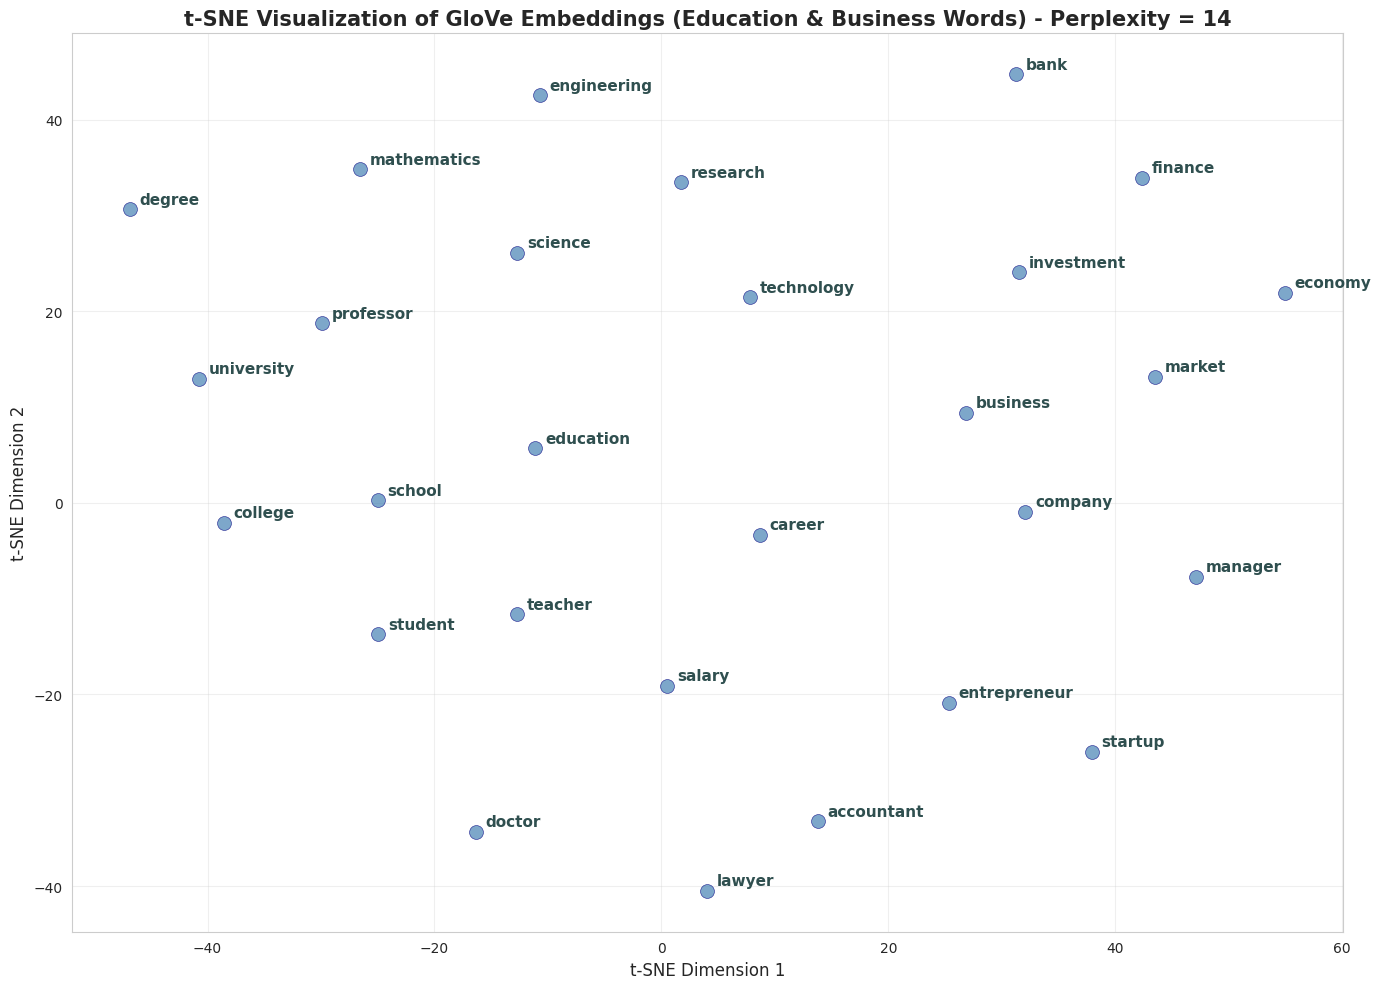

Plot saved as 'tsne_glove_perplexity_14'


In [44]:
# Run t-SNE
perplexity = 14
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, max_iter=2000)
embeddings_2d = tsne.fit_transform(word_vectors)

# Plot
plt.figure(figsize=(14, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='steelblue', s=100, alpha=0.7, edgecolors='navy', linewidths=0.5)

for i, word in enumerate(valid_words):
    plt.annotate(word,
                 xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 xytext=(7, 4),
                 textcoords='offset points',
                 fontsize=11,
                 fontweight='bold',
                 color='darkslategray')

plt.title(f't-SNE Visualization of GloVe Embeddings (Education & Business Words) - Perplexity = {perplexity}', fontsize=15, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"tsne_glove_perplexity_{perplexity}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved as 'tsne_glove_perplexity_{perplexity}'")

Το πρώτο διάγραμμα έχει perplexity = 2. Σχηματίζονται 5-6 ξεκάθαρες ομάδες, που βγάζουν νόημα. Ενδιαφέρον έχει το γεγονός ότι το career απέχει πολύ απο την ακαδημαϊκή και την τεχνολογική συστάδα, καθώς και ότι το enterpreneur/startup φαίνεται αποσχισμένο από το παραδοσιακό business!
![Perplexity = 2](/home/george/MScAI/NLP-2/tsne_glove_perplexity_2.png)
\
όσο μεγαλώνει το perplexity τα όρια μεταξύ των συστάδων αρχίζουν να χάνονται. Συνεχίζουμε να έχουμε γειτνιάσεις σχετικών όρων, ομως.
![Perplexity = 14](/home/george/MScAI/NLP-2/tsne_glove_perplexity_14.png)
\
Τέλος, για perplexity ίσο με τον αριθμό των όρων n-1 (27) βλέπουμε πως στο διάγραμμα οι όροι είναι ομοιόμορφα απλωμένοι στον χώρο, και οι σχετικές τους θέσεις παύουν να μας δίνουν κάποια χρήσιμη πληροφορία.
![Perplexity = 27](/home/george/MScAI/NLP-2/tsne_glove_perplexity_27.png)
